In [9]:
import numpy as np
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing._data import scale

In [2]:
spam_df = pd.read_csv("Spam.csv")

In [4]:
spam_df.head(10)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
5,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1
6,0.00,0.00,0.00,0.0,1.92,0.00,0.00,0.00,0.00,0.64,...,0.00,0.054,0.0,0.164,0.054,0.000,1.671,4,112,1
7,0.00,0.00,0.00,0.0,1.88,0.00,0.00,1.88,0.00,0.00,...,0.00,0.206,0.0,0.000,0.000,0.000,2.450,11,49,1
8,0.15,0.00,0.46,0.0,0.61,0.00,0.30,0.00,0.92,0.76,...,0.00,0.271,0.0,0.181,0.203,0.022,9.744,445,1257,1
9,0.06,0.12,0.77,0.0,0.19,0.32,0.38,0.00,0.06,0.00,...,0.04,0.030,0.0,0.244,0.081,0.000,1.729,43,749,1


In [6]:
spam_df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [7]:
target_variable = "spam"
feature_columns = [col for col in spam_df.columns if col != target_variable]
X = spam_df[[col for col in spam_df.columns if col != target_variable]]
y = spam_df[target_variable]

In [8]:
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


In [10]:
scaled_X = scale(X)

In [11]:
scaled_X

array([[-3.42433707e-01,  3.30884903e-01,  7.12858774e-01, ...,
        -4.52472762e-02,  4.52979198e-02, -8.72413388e-03],
       [ 3.45359395e-01,  5.19091945e-02,  4.35129540e-01, ...,
        -2.44326749e-03,  2.50562832e-01,  1.22832407e+00],
       [-1.45921392e-01, -1.65071912e-01,  8.51723390e-01, ...,
         1.45920848e-01,  2.22110599e+00,  3.25873251e+00],
       ...,
       [ 6.40127868e-01, -1.65071912e-01,  3.83734930e-02, ...,
        -1.19382054e-01, -2.36941335e-01, -2.72627750e-01],
       [ 2.80176333e+00, -1.65071912e-01, -5.56760578e-01, ...,
        -1.27482666e-01, -2.42072958e-01, -3.38603654e-01],
       [-3.42433707e-01, -1.65071912e-01,  7.32696576e-01, ...,
        -1.24236117e-01, -2.42072958e-01, -4.01280763e-01]])

In [13]:
y = y.values.astype(int)

In [14]:
y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, y, train_size=0.7, random_state=460
)

In [18]:
len(X_train)

3220

In [19]:
print(np.mean(y_train))
print(np.mean(y_test))

0.39751552795031053
0.38595220854453294


In [21]:
# Starting with best guess SCV C=10
model = SVC(C=10)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

print(f"Train accuracy: {metrics.accuracy_score(y_train_pred,y_train)}")

print(f"Test accuracy: {metrics.accuracy_score(y_test_pred,y_test)}")

Train accuracy: 0.9677018633540373
Test accuracy: 0.9275887038377987


In [23]:
print(metrics.classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1940
           1       0.97      0.95      0.96      1280

    accuracy                           0.97      3220
   macro avg       0.97      0.96      0.97      3220
weighted avg       0.97      0.97      0.97      3220



In [24]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       848
           1       0.91      0.90      0.91       533

    accuracy                           0.93      1381
   macro avg       0.92      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381



In [25]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[803,  45],
       [ 55, 478]])

In [39]:
actual_0 = len(y_test) - y_test.sum()
actual_1 = y_test.sum()
predicted_1 = y_test_pred.sum()
predicted_0 = len(y_test_pred) - y_test_pred.sum()
cm = pd.DataFrame({"0": [actual_0, actual_1], "1": [actual_1, predicted_0]})
cm

,0,1
0,848,533
1,533,858


In [38]:
sum(y_test)

np.int64(533)

In [40]:
help(metrics.confusion_matrix)

Help on function confusion_matrix in module sklearn.metrics._classification:

confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)
    Compute confusion matrix to evaluate the accuracy of a classification.

    By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
    is equal to the number of observations known to be in group :math:`i` and
    predicted to be in group :math:`j`.

    Thus in binary classification, the count of true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

    Read more in the :ref:`User Guide <confusion_matrix>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,)
        Estimated targets as returned by a classifier.

    labels : array-like of shape (n_classes), default=None
        List of lab

# Cross Validation for best accuracy

In [41]:
from sklearn.model_selection import KFold, cross_val_score

# Finding the best cost C for which our model gives best accuracy/precision/recall

# param_grid = {"C":[.03,.05,.07,.1,5,10,20,30,40,50,100,1000]}

folds = KFold(n_splits=5, shuffle=True, random_state=460)

model = SVC(C=10)

# computing the cross-validation scores
# note that the argument cv takes the 'folds' object, and
# we have specified 'accuracy' as the metric

cv_results = cross_val_score(model, X_train, y_train, cv=folds, scoring="accuracy")

print(cv_results)
print("mean accuracy = {}".format(cv_results.mean()))

[0.94409938 0.93012422 0.92857143 0.92857143 0.94099379]
mean accuracy = 0.9344720496894411


## Grid Search to Find Optimal Hyperparameter C

K-fold CV helps us compute average metrics over multiple folds, and that is the best indication of the 'test accuracy/other metric scores' we can have.

But we want to use CV to compute the optimal values of hyperparameters (in this case, the cost C is a hyperparameter). This is done using the ```GridSearchCV()``` method, which computes metrics (such as accuracy, recall etc.)

In this case, we have only one hyperparameter, though you can have multiple, such as C and gamma in non-linear SVMs. In that case, you need to search through a *grid* of multiple values of C and gamma to find the optimal combination, and hence the name GridSearchCV.

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.03, 0.05, 0.07, 0.1, 5, 10, 100]}
model = SVC()
model_cv = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=folds,
    verbose=1,
    return_train_score=True,
)

## Hyper parameter tuning is the costliest operation

In [43]:
model_cv.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,SVC()
,param_grid,"{'C': [0.03, 0.05, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,C,5


In [44]:
dir(model_cv)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_refit_for_multimetric',
 '_check_scorers_accept_sample_weight',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_format_results',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params_html',
 '_get_routed_params_for_fit',
 '_get_scorers',
 '_html_repr',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_run_sea

In [47]:
result = pd.DataFrame(model_cv.cv_results_)
result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.097591,0.004194,0.076660,0.005486,0.03,{'C': 0.03},0.861801,0.885093,0.875776,0.878882,...,0.870497,0.012407,12,0.871894,0.876941,0.880047,0.869565,0.872283,0.874146,0.003799
1,0.083083,0.000923,0.065149,0.000645,0.05,{'C': 0.05},0.886646,0.895963,0.899068,0.895963,...,0.890062,0.009642,11,0.894798,0.897904,0.897904,0.894022,0.892857,0.895497,0.002060
2,0.075861,0.000902,0.061074,0.002024,0.07,{'C': 0.07},0.888199,0.902174,0.914596,0.905280,...,0.899379,0.010595,10,0.902950,0.904503,0.904115,0.901009,0.903339,0.903183,0.001218
3,0.069461,0.000532,0.055586,0.001874,0.10,{'C': 0.1},0.900621,0.903727,0.923913,0.906832,...,0.905590,0.010272,9,0.907997,0.909161,0.913043,0.909161,0.913043,0.910481,0.002135
4,0.044168,0.001470,0.028673,0.000539,5.00,{'C': 5},0.940994,0.933230,0.933230,0.936335,...,0.937888,0.004811,1,0.963898,0.965062,0.964286,0.965839,0.961180,0.964053,0.001584
5,0.044551,0.001185,0.026595,0.001245,10.00,{'C': 10},0.944099,0.930124,0.928571,0.928571,...,0.934472,0.006690,2,0.968168,0.970497,0.970109,0.971661,0.964674,0.969022,0.002448
6,0.048265,0.001550,0.025058,0.001409,20.00,{'C': 20},0.937888,0.928571,0.931677,0.920807,...,0.931677,0.006733,5,0.973991,0.978261,0.977484,0.982531,0.975155,0.977484,0.002956
7,0.049936,0.002075,0.025107,0.001628,30.00,{'C': 30},0.937888,0.930124,0.934783,0.923913,...,0.932919,0.005325,3,0.978649,0.984472,0.980202,0.984860,0.979814,0.981599,0.002559
8,0.051629,0.002429,0.025061,0.001210,40.00,{'C': 40},0.934783,0.927019,0.937888,0.922360,...,0.931677,0.005974,4,0.982531,0.986025,0.981755,0.986025,0.982143,0.983696,0.001918
9,0.054119,0.001806,0.024638,0.000889,50.00,{'C': 50},0.934783,0.928571,0.931677,0.922360,...,0.930124,0.004392,6,0.984084,0.987189,0.984084,0.987966,0.982919,0.985248,0.001964


In [48]:
model_cv.best_estimator_

,C,5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [54]:
model_cv.best_score_

np.float64(0.9378881987577639)

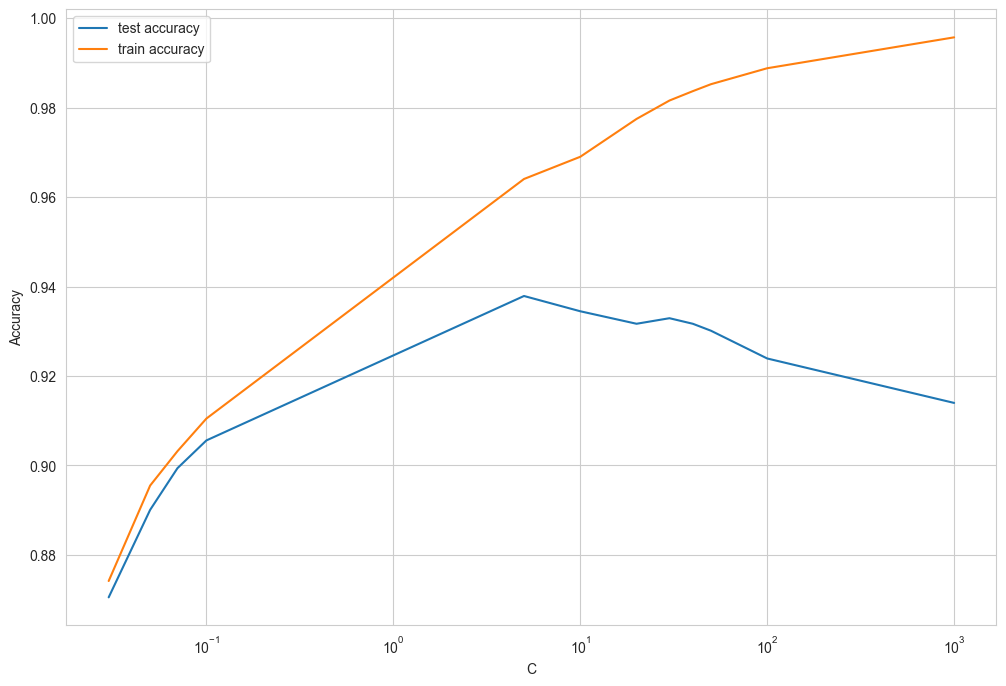

In [53]:
plt.figure(figsize=(12, 8))
plt.plot(result["param_C"], result["mean_test_score"])
plt.plot(result["param_C"], result["mean_train_score"])
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend(["test accuracy", "train accuracy"], loc="upper left")
plt.xscale("log")

In [55]:
best_score = model_cv.best_score_
best_C = model_cv.best_params_["C"]

print(" The highest test accuracy is {0} at C = {1}".format(best_score, best_C))

 The highest test accuracy is 0.9378881987577639 at C = 5


In [60]:
model = SVC(C=best_C)

# fit
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)
# metrics
# print other metrics

# accuracy
print("accuracy", metrics.accuracy_score(y_test, y_pred))

# precision
print("precision", metrics.precision_score(y_test, y_pred))

# recall/sensitivity
print("recall", metrics.recall_score(y_test, y_pred))

accuracy 0.9275887038377987
precision 0.9155470249520153
recall 0.8949343339587242


In [61]:
# specify scores/metrics in an iterable
scores = ["accuracy", "precision", "recall"]

for score in scores:
    print("# Tuning hyper-parameters for {}".format(score))

    # set up GridSearch for score metric
    clf = GridSearchCV(
        SVC(), param_grid=param_grid, cv=folds, scoring=score, return_train_score=True
    )
    # fit
    clf.fit(X_train, y_train)

    print(
        " The highest {0} score is {1} at C = {2}".format(
            score, clf.best_score_, clf.best_params_
        )
    )
    print("\n")

# Tuning hyper-parameters for accuracy
 The highest accuracy score is 0.9378881987577639 at C = {'C': 5}


# Tuning hyper-parameters for precision
 The highest precision score is 0.951916557683122 at C = {'C': 0.03}


# Tuning hyper-parameters for recall
 The highest recall score is 0.8980773570646354 at C = {'C': 5}


